## Problem 8.3 - Regression with Kernel

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.kernel_ridge import KernelRidge
from sklearn.model_selection import GridSearchCV

In [18]:
np.random.seed(42)

In [19]:
def f_1(x):
    return np.sin(4 * np.pi * x)

In [37]:
def f_2(x): 
    x = np.array(x)
    return 4 * np.maximum(0, x - 1/2) - 1

In [21]:
def f_3(x):
    x = np.array(x)
    return np.piecewise(x,
        [ (0 <= x) & (x <= 1/4),
          (1/4 < x) & (x <= 1/2),
          (1/2 < x) & (x <= 3/4),
          (3/4 < x) & (x <= 1)],
        [lambda x: -1 + 8 * x,
         lambda x: 1 - 8 * (x - 1/4),
         lambda x: -1 + 8 * (x - 1/2),
         lambda x: 1 - 8 * (x - 3/4)]
    )

In [22]:
def f_4(x):
    return np.piecewise(x,
        [ (0 <= x) & (x <= 1/4),
          (1/4 < x) & (x <= 1/2),
          (1/2 < x) & (x <= 3/4),
          (3/4 < x) & (x <= 1)],
        [lambda x:  1,
         lambda x: -1,
         lambda x: 1,
         lambda x: -1])
        

In [40]:
# define the setting
n = 100
sd = 0.2
functions = {"f1": f_1, "f2": f_2, "f3":f_3, "f4": f_4}


#### Explanation of the param_grid we use:

- alpha: regularization parameter  
    large alpha -> strong regularization -> smoother approximation -> less likely to overfit  
    small alpha -> weak regularization -> fits data more closely -> overfitting likely  

- gamma: kernel width for RBF  
    large gamma -> narrow kernel -> model reacts strongly to nearby points -> overfitting  
    small gamma -> wide kernel -> smoother approximation -> may underfit  
    -> controls smoothness of the approximating function for RBF kernels  

- degree: polynomial degree  
    large degree -> higher-oder polynomials -> more flexible, but also more potential to overfit  
    small degree -> simpler polynomial approximation  

In [41]:
param_grid = {
        "alpha": [1, 1e-1, 1e-2, 1e-3],
        "gamma": np.logspace(-2, 2, 5),
        "degree": [2, 3, 5]
    }

In [71]:
def get_approximation(ax, func_name, function,  n_val, sd_val, kernel_type = 'rbf'):
    x = np.random.uniform(0, 1, size = n_val)
    y_true = function(x)
    y = y_true + np.random.normal(0, sd_val, size = n_val)

    kr = GridSearchCV(KernelRidge(kernel = kernel_type), param_grid = param_grid)
    kr.fit(x.reshape(-1, 1), y)
    
    x_plot = np.linspace(0, 1, 100)
    y_pred = kr.predict(x_plot.reshape(-1, 1))
    
    ax.scatter(x, y, color='pink', alpha=0.5, label = 'Noisy observations')
    ax.plot(x_plot, function(x_plot), color = 'hotpink', label = 'Ground truth', linewidth = 2)
    ax.plot(x_plot, y_pred, color = 'purple', label = 'Approximation', linewidth = 2)
    ax.set_title(f'{kernel_type.upper()} | n={n_val}, sd={sd_val}\n', fontsize=10)
    ax.set_xlabel('x')
    ax.set_ylabel(f"{func_name}(x)")
    ax.grid(True)




### (i) Plot the approximation, the ground truth and the datapoints for each function

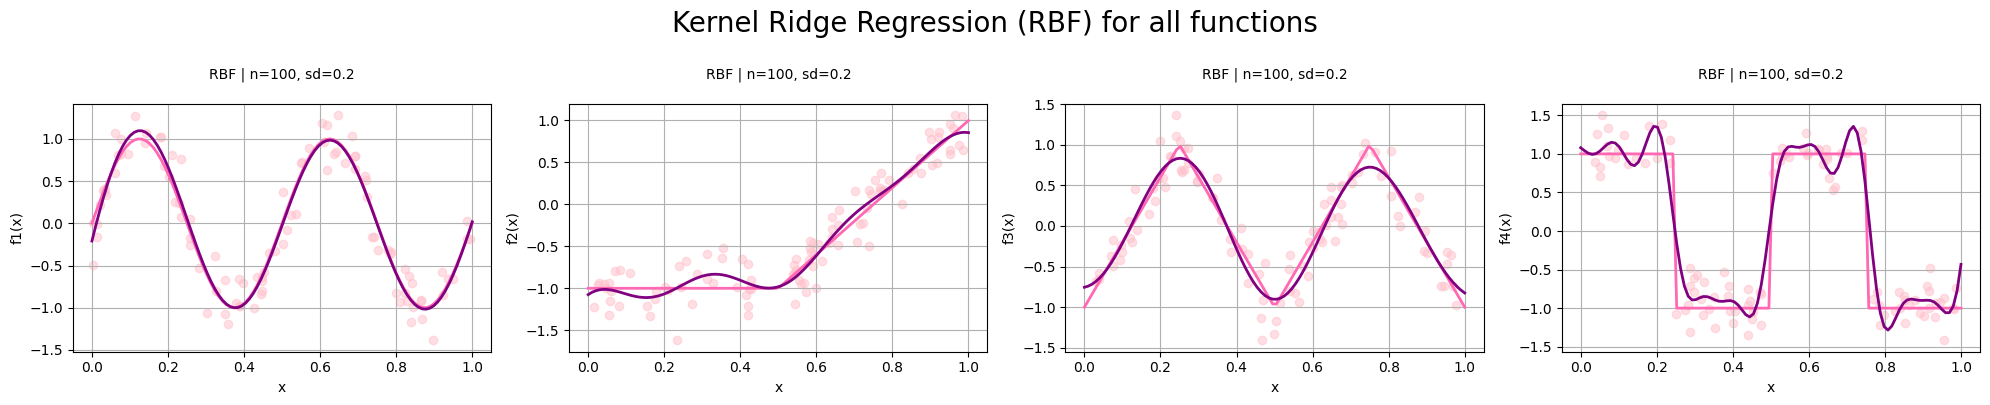

In [72]:

fig, axes = plt.subplots(1, len(functions), figsize=(5 * len(functions), 4))
fig.suptitle("Kernel Ridge Regression (RBF) for all functions", fontsize = 20, y = 1)

axes = np.array(axes).reshape(-1)

for ax, (func_name, func) in zip(axes, functions.items()):
    get_approximation(ax, func_name, func, n, sd, kernel_type='rbf')

plt.tight_layout()
plt.show()


### (ii) Experimenting with different sample sizes n

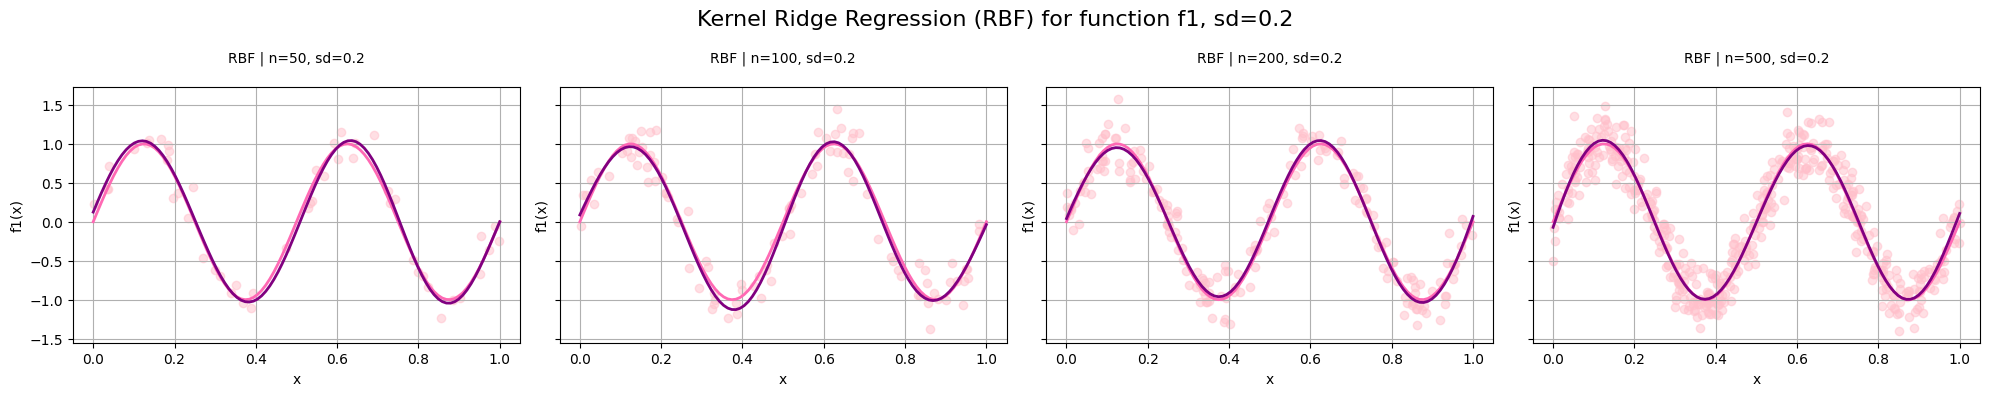

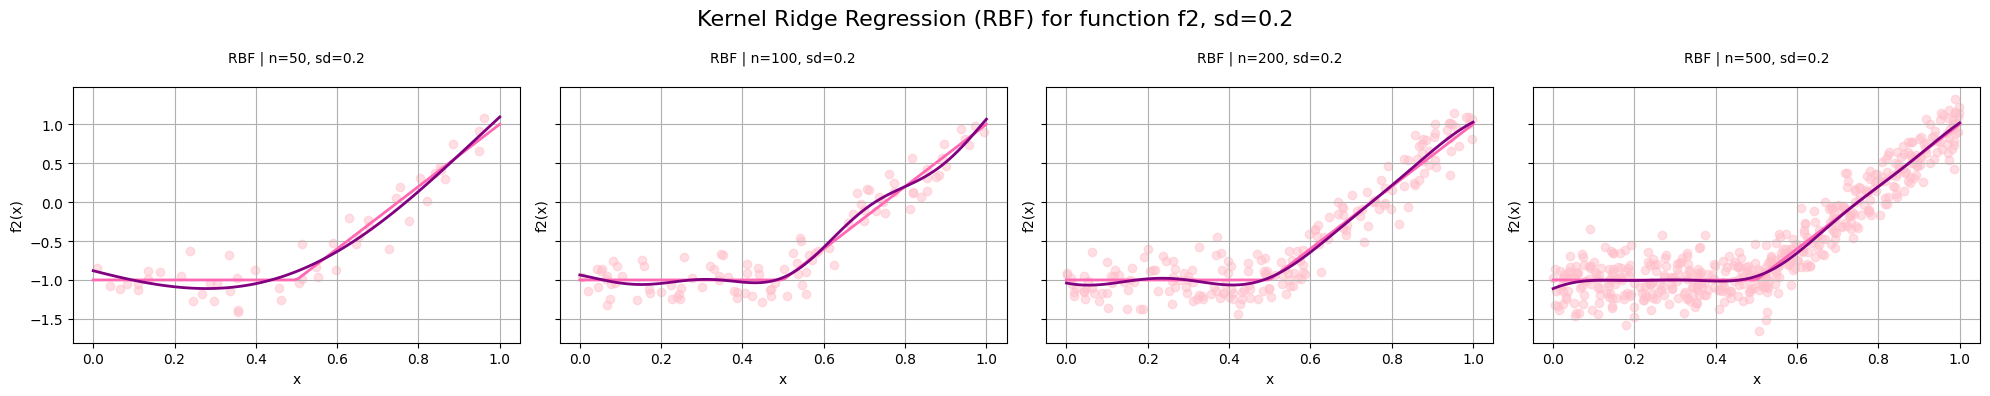

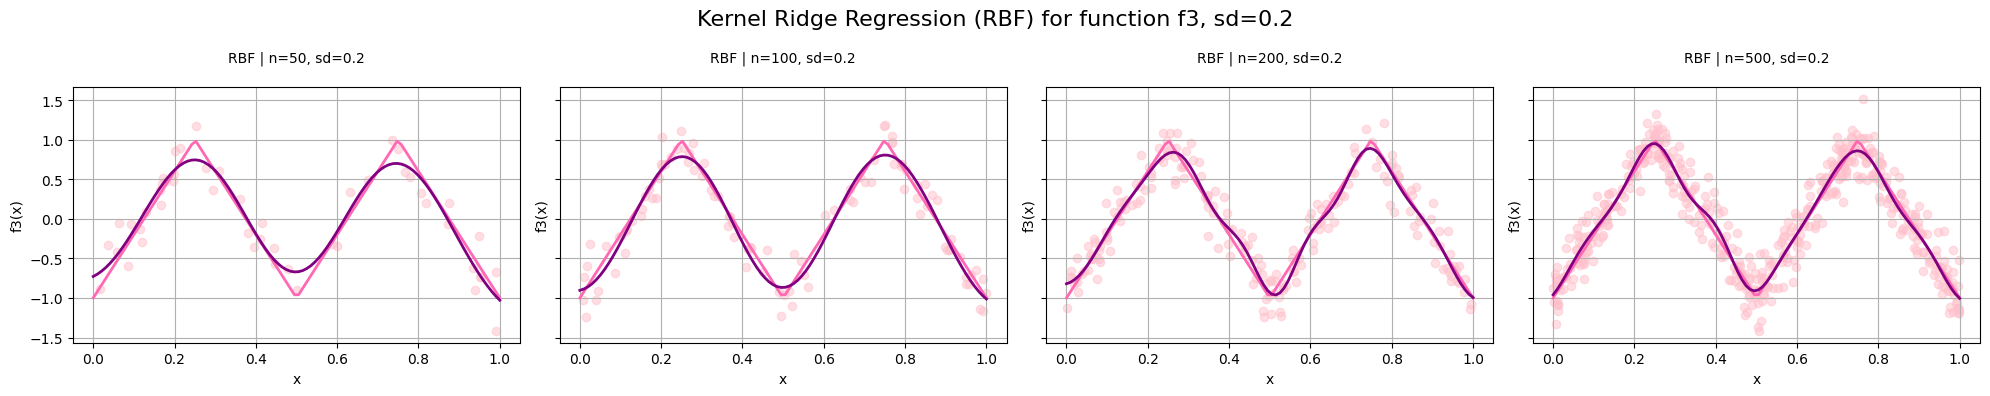

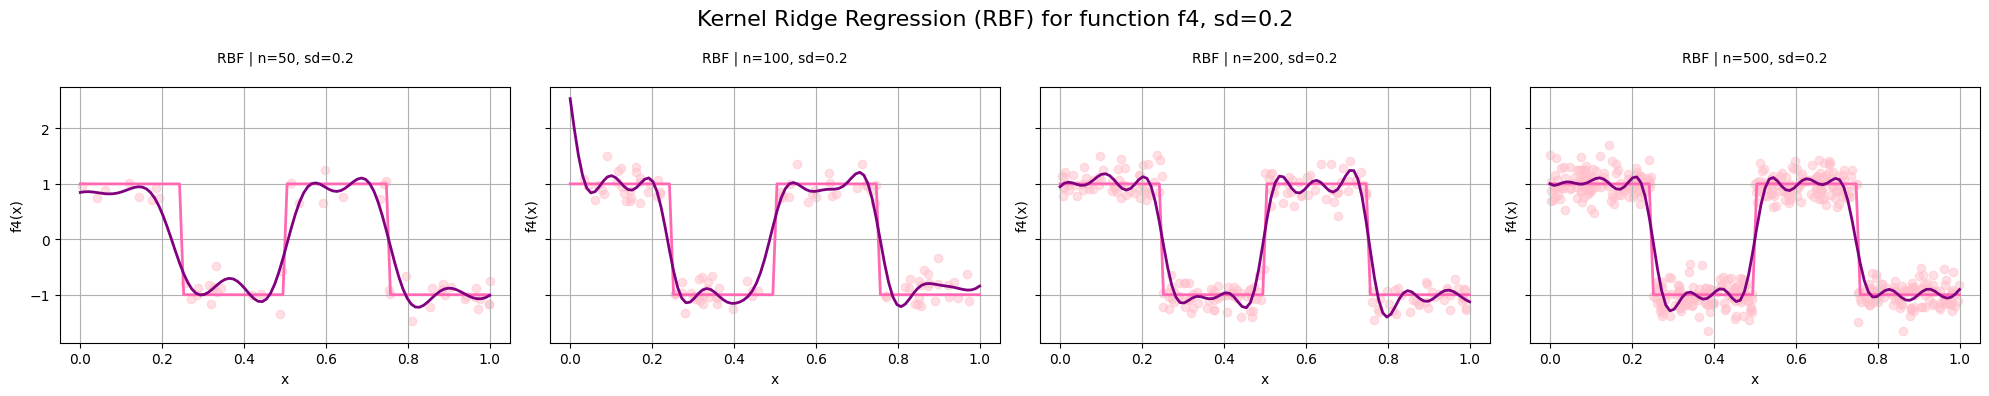

In [73]:
n_values = [50, 100, 200, 500]

for func_name, func in functions.items():
    fig, axes = plt.subplots(1, len(n_values), figsize=(5 * len(n_values), 4), sharey = True)
    fig.suptitle(f"Kernel Ridge Regression (RBF) for function {func_name}, sd={sd}", fontsize = 16)

    axes = np.array(axes).reshape(-1) 

    for ax, n_val in zip(axes, n_values):
        get_approximation(ax, func_name, func, n_val, sd, kernel_type = 'rbf')

    plt.tight_layout()
    plt.show()

Overall the approximation visually seems to get better with a larger sample size

### (iii) Experiment with different sigmas

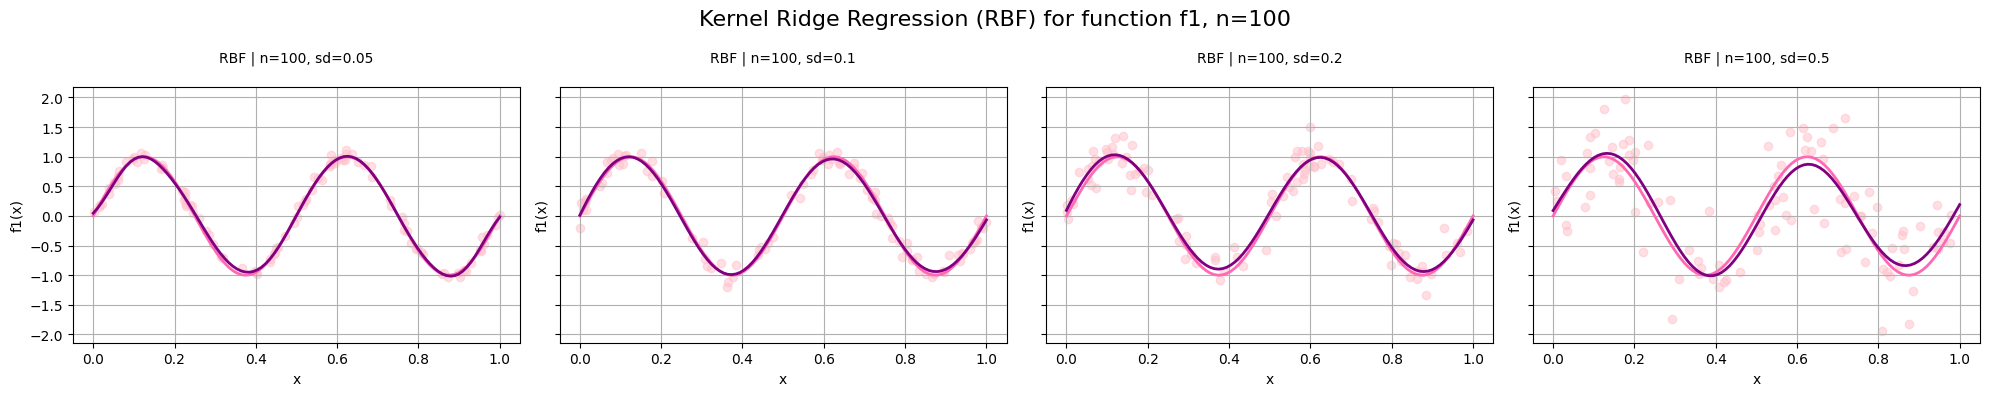

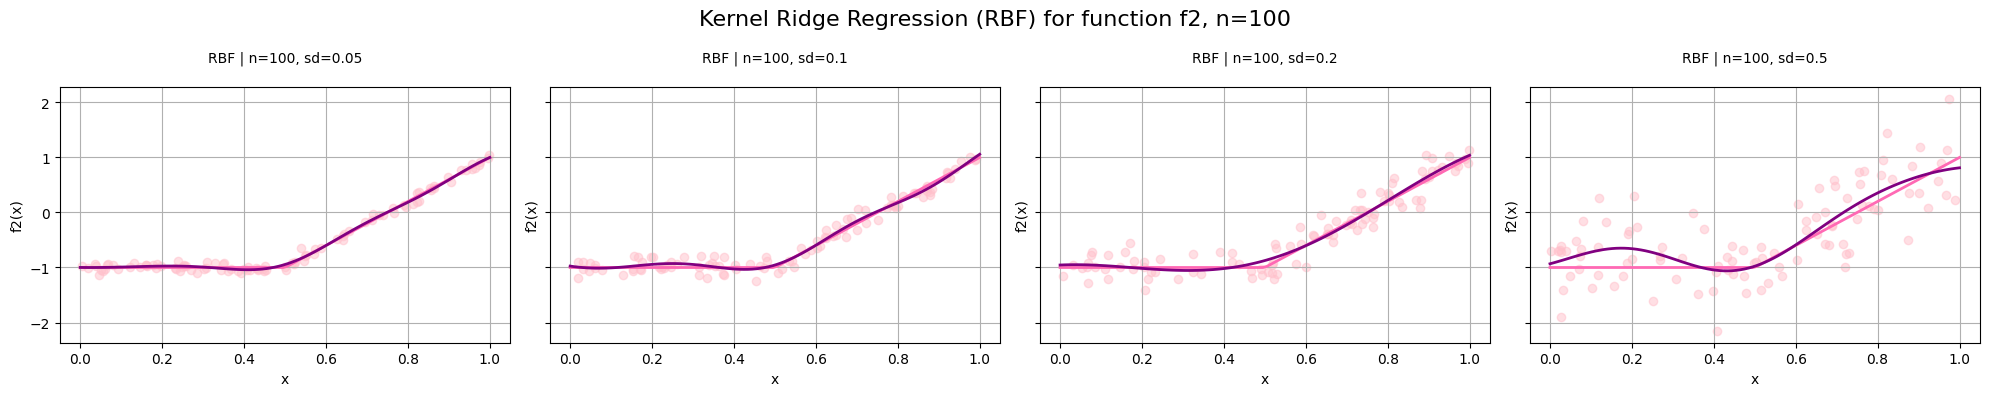

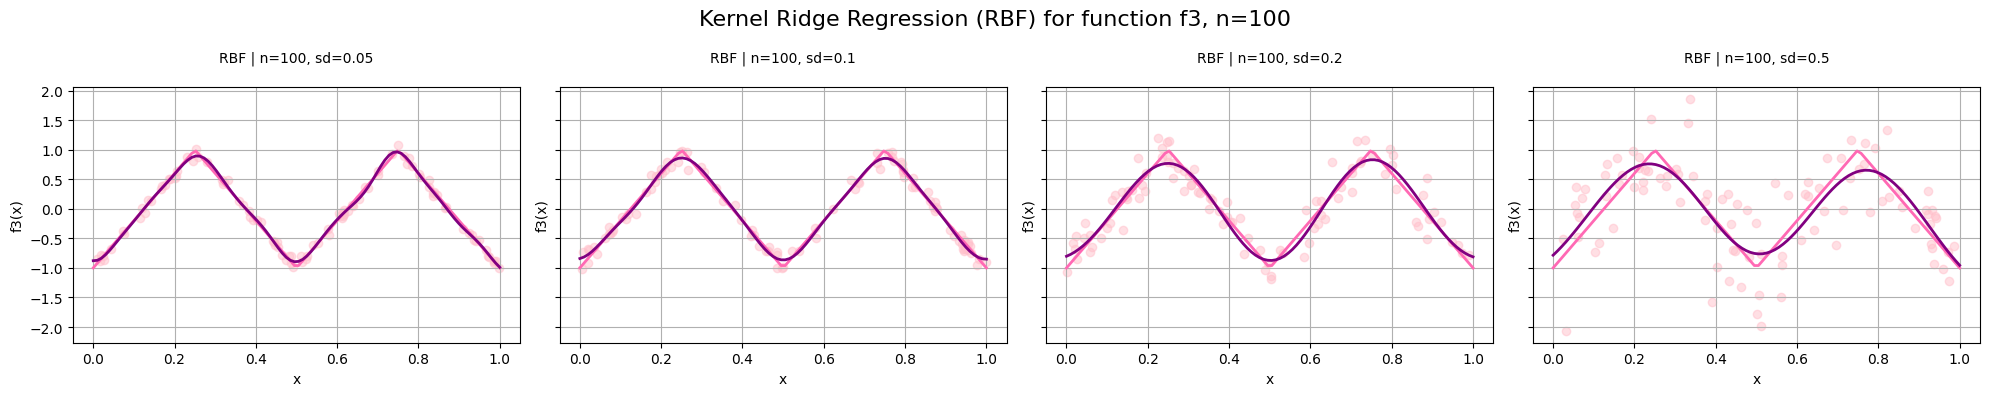

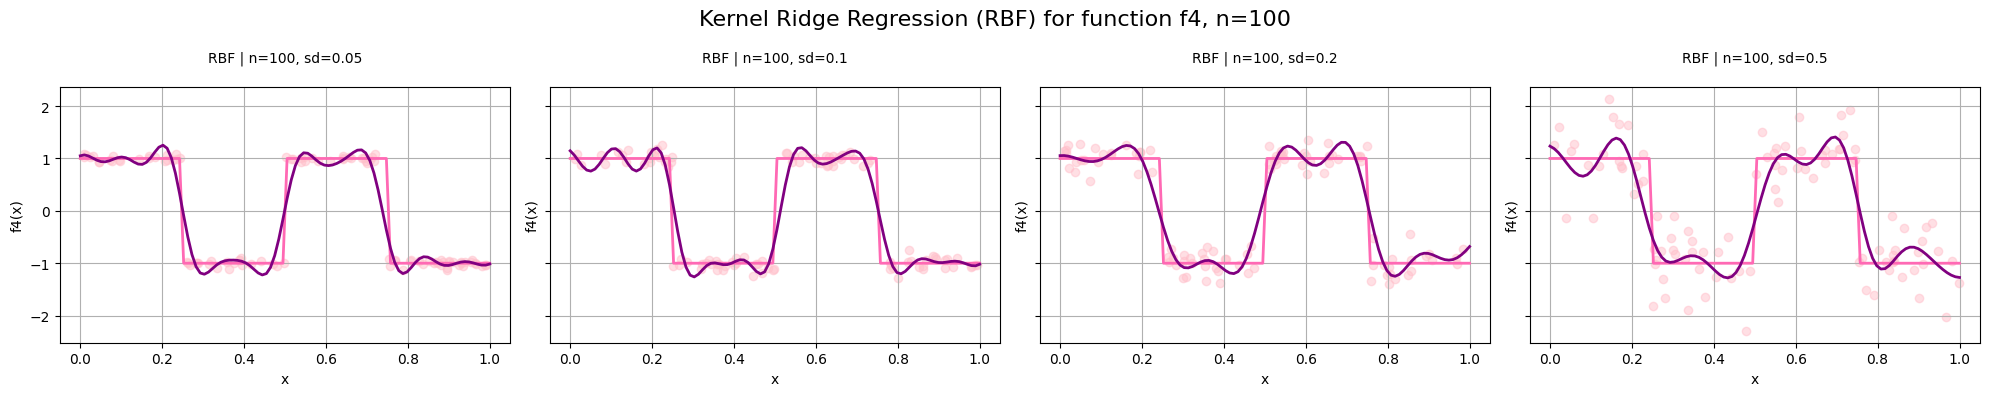

In [74]:
sigmas = [0.05, 0.1, 0.2, 0.5]

for func_name, func in functions.items():
    fig, axes = plt.subplots(1, len(sigmas), figsize=(5 * len(sigmas), 4), sharey = True)
    fig.suptitle(f"Kernel Ridge Regression (RBF) for function {func_name}, n={n}", fontsize=16)

    axes = np.array(axes).reshape(-1) 

    for ax, sigma in zip(axes, sigmas):
        get_approximation(ax, func_name, func, n, sigma, kernel_type = 'rbf')

    plt.tight_layout()
    plt.show()

Overall a lower standard deviation visually seems to work better for approximation

### (iv) Experiment with different kernels

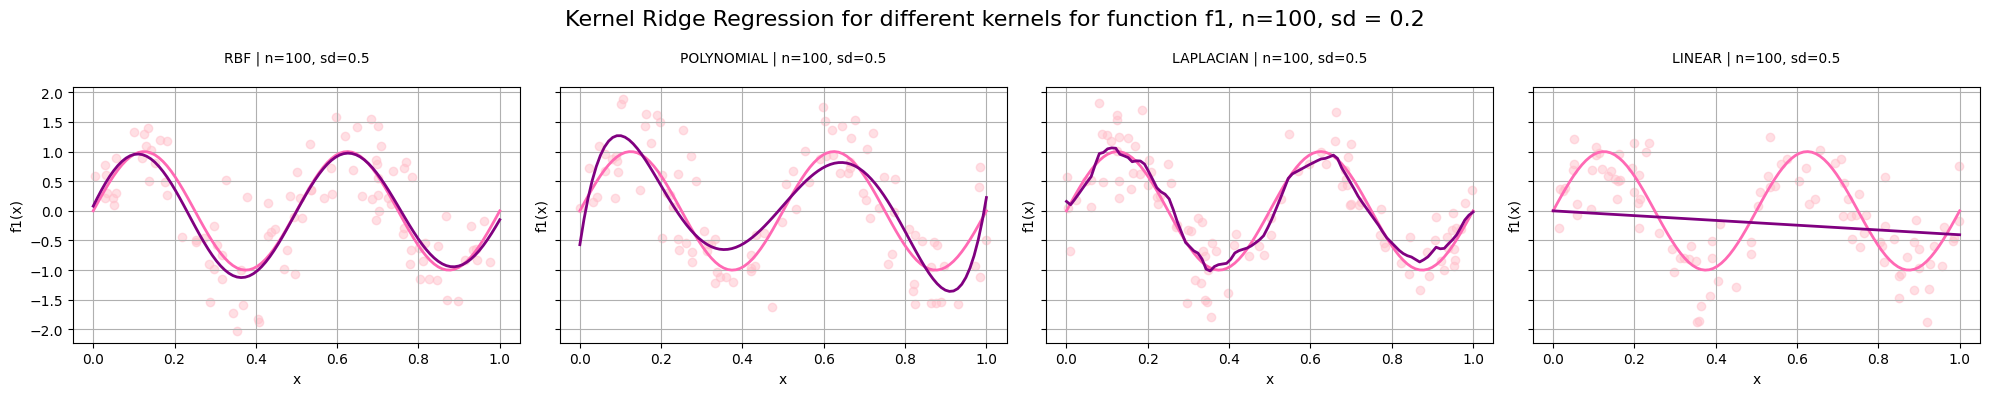

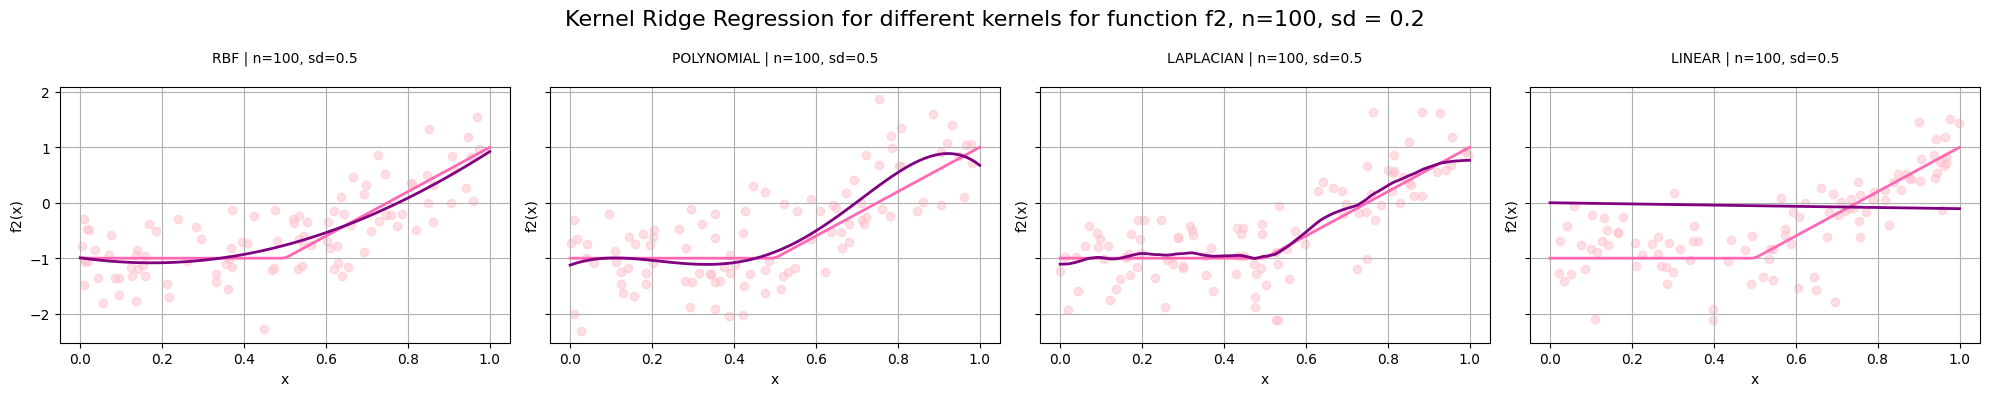

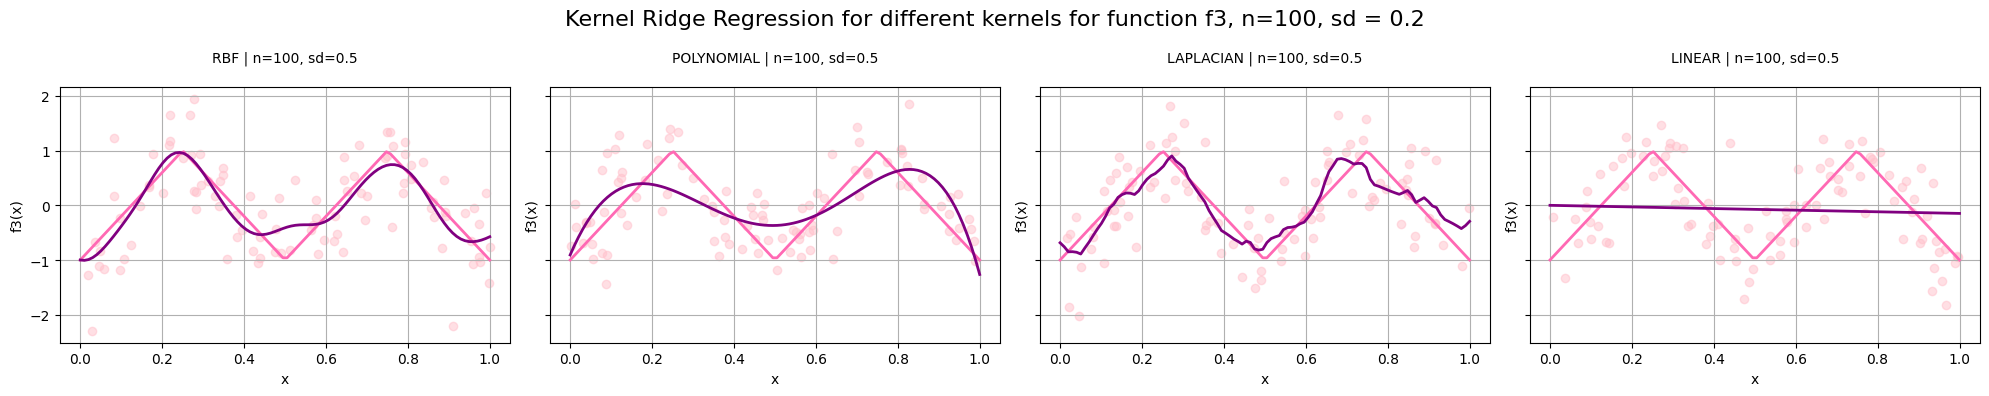

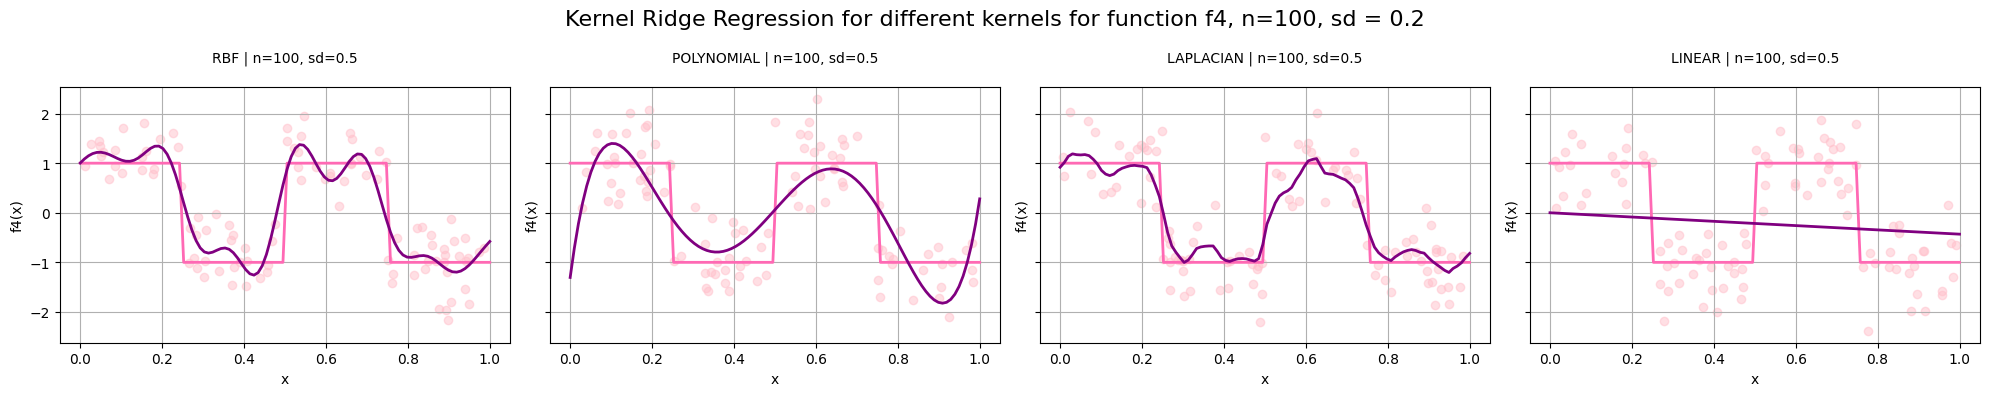

In [75]:
kernels = ['rbf', 'polynomial', 'laplacian', 'linear']

for func_name, func in functions.items():
    fig, axes = plt.subplots(1, len(sigmas), figsize=(5 * len(sigmas), 4), sharey = True)
    fig.suptitle(f"Kernel Ridge Regression for different kernels for function {func_name}, n={n}, sd = {sd}", fontsize=16)

    axes = np.array(axes).reshape(-1) 

    for ax, kernel in zip(axes, kernels):
        get_approximation(ax, func_name, func, n, sigma, kernel_type = kernel)

    plt.tight_layout()
    plt.show()

**RBF:**